In [1]:
from google.colab import files

uploaded = files.upload()

Saving results40.csv to results40.csv


In [2]:
import pandas as pd

df = pd.read_csv("results40.csv")

In [14]:
import pandas as pd

filtered_df = df[df['model'] != "Qwen/Qwen2.5-Coder-3B"]

run_counts = (
    filtered_df.groupby(['project', 'bug_id'])['run_id']
    .count()
    .reset_index(name='runs')
)

final_bugs = run_counts[run_counts['runs'] >= 60]

print("Final bugs count:", len(final_bugs))

final_bugs

Final bugs count: 38


,project,bug_id,runs
0,ansible,1,60
1,ansible,3,60
2,ansible,7,60
3,ansible,9,60
4,ansible,11,60
5,ansible,15,60
6,black,1,60
7,black,2,60
8,black,3,60
9,black,5,60


In [15]:
run_counts = (
    df.groupby(['project', 'bug_id'])['run_id']
    .count()
    .reset_index(name='runs')
)

final_bugs = run_counts[run_counts['runs'] >= 60]

In [16]:
clean_df = df.merge(
    final_bugs[['project','bug_id']],
    on=['project','bug_id']
)

In [17]:
check = clean_df.groupby(['model','project','bug_id'])['run_id'].count().reset_index(name='runs')

valid_pairs = check[check['runs'] == 10]

clean_df = clean_df.merge(
    valid_pairs[['model','project','bug_id']],
    on=['model','project','bug_id']
)

In [18]:
clean_df['accuracy'] = clean_df['post_test_pass'] / clean_df['post_total']

In [19]:
bug_model_avg = clean_df.groupby(['model','project','bug_id']).agg({
    'accuracy': 'mean'
}).reset_index()

In [20]:
bug_model_avg['is_pass'] = (bug_model_avg['accuracy'] == 1.0).astype(int)

In [21]:
bug_model_avg.sort_values(by=['model','project','bug_id'])

,model,project,bug_id,accuracy,is_pass
0,Qwen/Qwen2.5-Coder-1.5B,ansible,1,0.0,0
1,Qwen/Qwen2.5-Coder-1.5B,ansible,3,0.0,0
2,Qwen/Qwen2.5-Coder-1.5B,ansible,7,1.0,1
3,Qwen/Qwen2.5-Coder-1.5B,ansible,9,0.0,0
4,Qwen/Qwen2.5-Coder-1.5B,ansible,11,1.0,1
...,...,...,...,...,...
214,stabilityai/stablecode-3b,tqdm,5,NaN,0
215,stabilityai/stablecode-3b,tqdm,7,0.0,0
216,stabilityai/stablecode-3b,tqdm,9,0.0,0
217,stabilityai/stablecode-3b,youtube-dl,1,0.0,0


In [22]:
pass_count = bug_model_avg.groupby('model')['is_pass'].sum().reset_index(name='bugs_passed')
pass_count

,model,bugs_passed
0,Qwen/Qwen2.5-Coder-1.5B,11
1,Qwen/Qwen2.5-Coder-3B,1
2,bigcode/starcoder2-15b,2
3,bigcode/starcoder2-7b,3
4,codellama/CodeLlama-13b-Instruct-hf,7
5,deepseek-ai/deepseek-coder-6.7b-instruct,0
6,stabilityai/stablecode-3b,1


In [23]:
clean_df['is_success'] = (clean_df['post_test_pass'] == clean_df['post_total']).astype(int)

bug_model_stats = clean_df.groupby(['model','project','bug_id']).agg({
    'is_success': 'sum'  # Ye btaye ga 10 mein se kitni bar bug fix hua
}).reset_index()

bug_model_stats['pass_at_1'] = bug_model_stats['is_success'] / 10.0

In [24]:
model_map = {
    "Qwen/Qwen2.5-Coder-1.5B": "Qwen1.5",
    "stabilityai/stablecode-3b": "StableCode3",
    "deepseek-ai/deepseek-coder-6.7b-instruct": "DeepSeek6",
    "bigcode/starcoder2-7b": "StarCoder7",
    "codellama/CodeLlama-13b-Instruct-hf": "CodeLlama13",
    "bigcode/starcoder2-15b": "StarCoder15"
}

In [25]:
bug_model_avg['model_label'] = bug_model_avg['model'].map(model_map)

In [26]:
#model order and color
model_order = [
    "Qwen1.5",
    "StableCode3",
    "DeepSeek6",
    "StarCoder7",
    "CodeLlama13",
    "StarCoder15"
]

bug_model_avg['model_label'] = pd.Categorical(
    bug_model_avg['model_label'],
    categories=model_order,
    ordered=True
)
color_map = {
    "Qwen1.5": "#4C78A8",      # Blue
    "StableCode3": "#F58518",  # Orange
    "DeepSeek6": "#54A24B",    # Green
    "StarCoder7": "#E45756",   # Red-ish
    "CodeLlama13": "#B279A2",  # Purple
    "StarCoder15": "#72B7B2"   # Teal
}

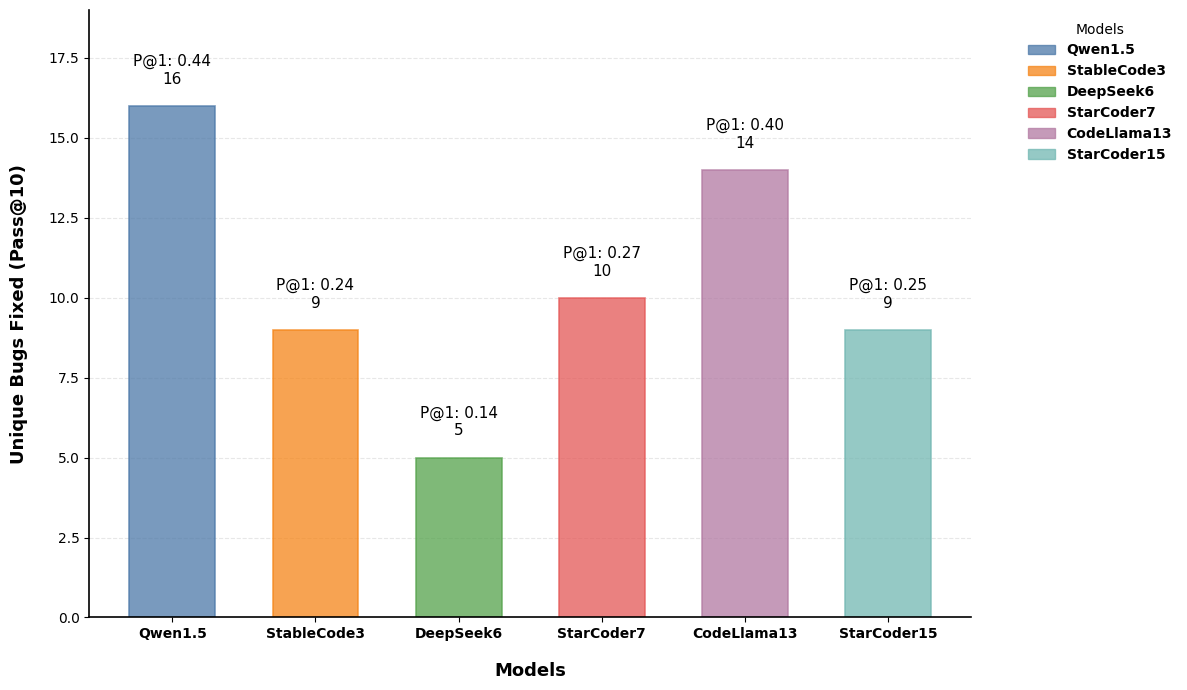

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

clean_df['is_success'] = (clean_df['post_test_pass'] == clean_df['post_total']).astype(int)

bug_model_stats = clean_df.groupby(['model','project','bug_id']).agg({'is_success': 'sum'}).reset_index()
bug_model_stats.rename(columns={'is_success': 'c'}, inplace=True)
bug_model_stats['pass_at_1'] = bug_model_stats['c'] / 10.0

model_map = {
    "Qwen/Qwen2.5-Coder-1.5B": "Qwen1.5",
    "stabilityai/stablecode-3b": "StableCode3",
    "deepseek-ai/deepseek-coder-6.7b-instruct": "DeepSeek6",
    "bigcode/starcoder2-7b": "StarCoder7",
    "codellama/CodeLlama-13b-Instruct-hf": "CodeLlama13",
    "bigcode/starcoder2-15b": "StarCoder15"
}

model_order = ["Qwen1.5", "StableCode3", "DeepSeek6", "StarCoder7", "CodeLlama13", "StarCoder15"]

color_map = {
    "Qwen1.5": "#4C78A8",      # Blue
    "StableCode3": "#F58518",  # Orange
    "DeepSeek6": "#54A24B",    # Green
    "StarCoder7": "#E45756",   # Red-ish
    "CodeLlama13": "#B279A2",  # Purple
    "StarCoder15": "#72B7B2"   # Teal
}

pass_count = bug_model_stats[bug_model_stats['c'] > 0].groupby('model').size().reset_index(name='bugs_passed')
pass_count = pass_count[pass_count['model'].isin(model_map.keys())].copy()
pass_count['model_label'] = pass_count['model'].map(model_map)
pass_count['model_label'] = pd.Categorical(pass_count['model_label'], categories=model_order, ordered=True)
pass_count = pass_count.sort_values('model_label').reset_index(drop=True)

model_avg_pass1 = bug_model_stats.groupby('model').agg({'pass_at_1': 'mean'}).reset_index()
model_avg_pass1 = model_avg_pass1[model_avg_pass1['model'].isin(model_map.keys())].copy()
model_avg_pass1['model_label'] = model_avg_pass1['model'].map(model_map)
model_avg_pass1['model_label'] = pd.Categorical(model_avg_pass1['model_label'], categories=model_order, ordered=True)
model_avg_pass1 = model_avg_pass1.sort_values('model_label').reset_index(drop=True)

plt.figure(figsize=(12, 7), facecolor='white')
ax = plt.gca()

x = range(len(pass_count))
y = pass_count['bugs_passed']

plt.ylim(0, max(y) + 3)

bars = []
for i in range(len(pass_count)):
    label = pass_count.iloc[i]['model_label']
    color = color_map[label]
    y_val = y.iloc[i]

    # Pass@1 value
    p1_val = model_avg_pass1[model_avg_pass1['model_label'] == label]['pass_at_1'].values[0]

    bar = plt.bar(
        i,
        y_val,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        alpha=0.75,
        width=0.6,
        zorder=2
    )
    bars.append(bar)

    # Labels
    plt.text(
        i,
        y_val + 0.6,
        f"P@1: {p1_val:.2f}\n{int(y_val)}",
        ha='center',
        va='bottom',
        fontsize=11,
        color='black',
        zorder=3
    )

# Professional Formatting (unchanged)
plt.xticks(x, [row['model_label'] for idx, row in pass_count.iterrows()],
           fontsize=10, fontweight='bold', rotation=0)

plt.ylabel("Unique Bugs Fixed (Pass@10)", fontsize=13, fontweight='bold', labelpad=15)
plt.xlabel("Models", fontsize=13, fontweight='bold', labelpad=15)


# Subtle styling
plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Legend (updated for bars)
handles = [plt.Rectangle((0,0),1,1, color=color_map[m], alpha=0.75) for m in model_order]

plt.legend(handles, model_order, title="Models",
           bbox_to_anchor=(1.05, 1), loc='upper left',
           frameon=False, prop={'weight':'bold'})

plt.tight_layout()
plt.show()

In [29]:
import pandas as pd

df = pd.read_csv("results40.csv")


df = df.drop_duplicates(subset=['project','bug_id','model','run_id'])

run_counts = (
    df.groupby(['project','bug_id'])
    .size()
    .reset_index(name='runs')
)

final_bugs = run_counts[run_counts['runs'] == 60]

clean_df = df.merge(
    final_bugs[['project','bug_id']],
    on=['project','bug_id']
)

check = (
    clean_df.groupby(['model','project','bug_id'])
    .size()
    .reset_index(name='runs')
)

valid_pairs = check[check['runs'] == 10]

clean_df = clean_df.merge(
    valid_pairs[['model','project','bug_id']],
    on=['model','project','bug_id']
)


clean_df['is_success'] = (
    clean_df['post_test_pass'] == clean_df['post_total']
).astype(int)


runs_summary = clean_df.groupby('model').agg({
    'is_success': 'sum',
    'run_id': 'count'
}).reset_index()

runs_summary.rename(columns={
    'is_success': 'successful_runs',
    'run_id': 'total_runs'
}, inplace=True)

runs_summary['failed_runs'] = (
    runs_summary['total_runs'] - runs_summary['successful_runs']
)


bug_model_stats = clean_df.groupby(['model','project','bug_id']).agg({
    'is_success': 'sum'
}).reset_index()

bug_model_stats.rename(columns={'is_success': 'c'}, inplace=True)

bug_model_stats['pass_at_1'] = bug_model_stats['c'] / 10.0
pass1 = bug_model_stats.groupby('model')['pass_at_1'].mean().reset_index()

bugs_passed = (
    bug_model_stats[bug_model_stats['c'] > 0]
    .groupby('model')
    .size()
    .reset_index(name='bugs_passed')
)


clean_df['duration_seconds'] = pd.to_numeric(
    clean_df['duration_seconds'],
    errors='coerce'
)

avg_time = clean_df.groupby('model')['duration_seconds'].mean().reset_index(name='avg_time')


final_table = runs_summary.merge(bugs_passed, on='model')
final_table = final_table.merge(pass1, on='model')
final_table = final_table.merge(avg_time, on='model')

total_bugs = clean_df[['project','bug_id']].drop_duplicates().shape[0]
final_table['total_bugs'] = total_bugs

final_table['bugs_failed'] = (
    final_table['total_bugs'] - final_table['bugs_passed']
)

model_map = {
    "Qwen/Qwen2.5-Coder-1.5B": "Qwen1.5",
    "stabilityai/stablecode-3b": "StableCode3",
    "deepseek-ai/deepseek-coder-6.7b-instruct": "DeepSeek6",
    "bigcode/starcoder2-7b": "StarCoder7",
    "codellama/CodeLlama-13b-Instruct-hf": "CodeLlama13",
    "bigcode/starcoder2-15b": "StarCoder15"
}

size_map = {
    "Qwen1.5": "Small",
    "StableCode3": "Small",
    "DeepSeek6": "Small",
    "StarCoder7": "Medium",
    "CodeLlama13": "Medium",
    "StarCoder15": "Medium"
}

final_table['model'] = final_table['model'].map(model_map)
final_table['size'] = final_table['model'].map(size_map)


model_order = [
    "Qwen1.5",
    "StableCode3",
    "DeepSeek6",
    "StarCoder7",
    "CodeLlama13",
    "StarCoder15"
]

final_table['model'] = pd.Categorical(
    final_table['model'],
    categories=model_order,
    ordered=True
)

final_table = final_table.sort_values('model').reset_index(drop=True)


final_table['pass_at_1'] = final_table['pass_at_1'].round(2)
final_table['avg_time'] = final_table['avg_time'].round(1)


final_table = final_table[
    ['model','size','total_bugs','bugs_passed','bugs_failed',
     'pass_at_1','avg_time','successful_runs','failed_runs']
]

print(final_table)

         model    size  total_bugs  bugs_passed  bugs_failed  pass_at_1  \
0      Qwen1.5   Small          35           15           20       0.43   
1  StableCode3   Small          35            7           28       0.20   
2    DeepSeek6   Small          35            5           30       0.14   
3   StarCoder7  Medium          35            8           27       0.23   
4  CodeLlama13  Medium          35           14           21       0.40   
5  StarCoder15  Medium          35            8           27       0.23   

   avg_time  successful_runs  failed_runs  
0      38.7              150          200  
1      45.9               70          280  
2      54.1               50          300  
3      48.6               80          270  
4      68.4              140          210  
5      96.7               80          270  


In [30]:

project_bug_ids = (
    clean_df[['project','bug_id']]
    .drop_duplicates()
    .sort_values(['project','bug_id'])
)

# group into lists
project_bug_list = (
    project_bug_ids.groupby('project')['bug_id']
    .apply(list)
    .reset_index()
)

print("\n=== PROJECT → BUG IDS (USED IN EXPERIMENT) ===\n")

for _, row in project_bug_list.iterrows():
    print(f"{row['project']}: {row['bug_id']}")


=== PROJECT → BUG IDS (USED IN EXPERIMENT) ===

ansible: [1, 3, 7, 9, 11, 15]
black: [1, 2, 3, 5, 7, 9]
fastapi: [2, 8, 13, 15]
luigi: [1, 3, 5, 7, 9, 13]
sanic: [2]
scrapy: [2, 3, 5, 9, 11, 14]
tqdm: [3, 5, 7, 9]
youtube-dl: [1, 2]


In [31]:

bug_model_stats_clean = (
    clean_df.groupby(['model','project','bug_id'])['is_success']
    .sum()
    .reset_index(name='c')
)


total_bugs_per_project = (
    bug_model_stats_clean[['project','bug_id']]
    .drop_duplicates()
    .groupby('project')
    .size()
    .reset_index(name='total_bugs')
)


project_model_passed = (
    bug_model_stats_clean[bug_model_stats_clean['c'] > 0]
    .groupby(['project','model'])
    .size()
    .reset_index(name='bugs_passed')
)


project_model_passed = project_model_passed.merge(
    total_bugs_per_project,
    on='project'
)


project_model_passed['formatted'] = (
    project_model_passed['bugs_passed'].astype(str)
    + "/"
    + project_model_passed['total_bugs'].astype(str)
)


project_model_passed['model'] = project_model_passed['model'].map(model_map)


project_table = project_model_passed.pivot(
    index='project',
    columns='model',
    values='formatted'
)

total_map = dict(zip(
    total_bugs_per_project['project'],
    total_bugs_per_project['total_bugs']
))

for proj in project_table.index:
    for col in project_table.columns:
        if pd.isna(project_table.loc[proj, col]):
            project_table.loc[proj, col] = f"0/{total_map[proj]}"


project_table = project_table[model_order]

print("\n=== PROJECT PERFORMANCE (CLEAN / CONSISTENT) ===")
print(project_table)


=== PROJECT PERFORMANCE (CLEAN / CONSISTENT) ===
model   Qwen1.5 StableCode3 DeepSeek6 StarCoder7 CodeLlama13 StarCoder15
project                                                                 
ansible     2/6         0/6       0/6        0/6         2/6         0/6
fastapi     4/4         4/4       3/4        4/4         4/4         4/4
luigi       1/6         0/6       0/6        0/6         1/6         0/6
sanic       1/1         1/1       1/1        1/1         1/1         1/1
scrapy      3/6         0/6       0/6        0/6         3/6         1/6
tqdm        4/4         2/4       1/4        3/4         3/4         2/4


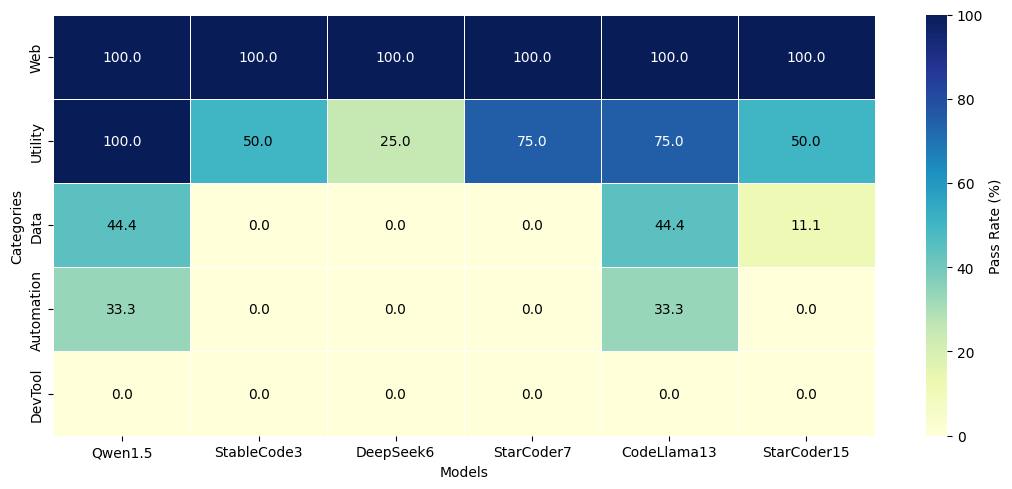

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

bug_model_stats_clean = (
    clean_df.groupby(['model','project','bug_id'])['is_success']
    .sum()
    .reset_index(name='c')
)

category_map = {
    'fastapi': 'Web',
    'sanic': 'Web',
    'black': 'DevTool',
    'cookiecutter': 'DevTool',
    'ansible': 'Automation',
    'luigi': 'Data',
    'scrapy': 'Data',
    'tqdm': 'Utility',
    'youtube-dl': 'Data'
}

bug_model_stats_clean['category'] = (
    bug_model_stats_clean['project'].str.lower().map(category_map)
)

# remove unmapped safely
bug_model_stats_clean = bug_model_stats_clean.dropna(subset=['category'])


category_total = (
    bug_model_stats_clean[['category','bug_id']]
    .drop_duplicates()
    .groupby('category')
    .size()
    .reset_index(name='total_bugs')
)


category_passed = (
    bug_model_stats_clean[bug_model_stats_clean['c'] > 0]
    [['category','model','bug_id']]
    .drop_duplicates()
    .groupby(['category','model'])
    .size()
    .reset_index(name='bugs_passed')
)


category_perf = category_passed.merge(category_total, on='category')

category_perf['pass_rate'] = (
    category_perf['bugs_passed'] / category_perf['total_bugs']
) * 100


category_perf['model'] = category_perf['model'].map(model_map)


all_categories = ['Web','Utility','Data','Automation','DevTool']
all_models = model_order  # already mapped labels

full_index = pd.MultiIndex.from_product(
    [all_categories, all_models],
    names=['category','model']
)

category_perf = (
    category_perf
    .set_index(['category','model'])
    .reindex(full_index)
    .reset_index()
)

category_perf['bugs_passed'] = category_perf['bugs_passed'].fillna(0)

category_perf['total_bugs'] = category_perf.groupby('category')['total_bugs'].transform('max')

category_perf['pass_rate'] = (
    category_perf['bugs_passed'] / category_perf['total_bugs']
) * 100

pivot_cat = category_perf.pivot(
    index='category',
    columns='model',
    values='pass_rate'
)

pivot_cat = pivot_cat.reindex(all_categories)
pivot_cat = pivot_cat[model_order].fillna(0)

color_list = [
    "#caf0f8",
    "#90e0ef",
    "#00b4d8",
    "#0077b6",
    "#023e8a",
    "#03045e"
]

custom_cmap = sns.color_palette("YlGnBu", as_cmap=True)


plt.figure(figsize=(11,5))

ax = sns.heatmap(
    pivot_cat,
    annot=True,
    fmt=".1f",
    cmap=custom_cmap,
    linewidths=0.5,
    cbar_kws={'label': 'Pass Rate (%)'},
    vmin=0,
    vmax=100
)


for text in ax.texts:
    value = float(text.get_text())
    text.set_color("white" if value >= 60 else "black")


plt.xlabel("Models")
plt.ylabel("Categories")

plt.tight_layout()
plt.show()

In [33]:
latex_table = final_table[
    ['model','size','bugs_passed','pass_at_1','avg_time']
].rename(columns={
    'model': '\\textbf{Model}',
    'size': '\\textbf{Size}',
    'bugs_passed': '\\textbf{Bugs Passed}',
    'pass_at_1': '\\textbf{Pass@1}',
    'avg_time': '\\textbf{Avg Time (s)}'
}).to_latex(
    index=False,
    escape=False
)

print(latex_table)

\begin{tabular}{llrrr}
\toprule
\textbf{Model} & \textbf{Size} & \textbf{Bugs Passed} & \textbf{Pass@1} & \textbf{Avg Time (s)} \\
\midrule
Qwen1.5 & Small & 15 & 0.430000 & 38.700000 \\
StableCode3 & Small & 7 & 0.200000 & 45.900000 \\
DeepSeek6 & Small & 5 & 0.140000 & 54.100000 \\
StarCoder7 & Medium & 8 & 0.230000 & 48.600000 \\
CodeLlama13 & Medium & 14 & 0.400000 & 68.400000 \\
StarCoder15 & Medium & 8 & 0.230000 & 96.700000 \\
\bottomrule
\end{tabular}



In [36]:
filtered['failed'] = 10 - filtered['c']

pivot_failed = filtered.pivot_table(
    index='bug_label',
    columns='model_label',
    values='failed'
).fillna(0)

print(pivot_failed)

model_label  Qwen1.5  StableCode3  DeepSeek6  StarCoder7  CodeLlama13  \
bug_label                                                               
Ansible 11       0.0         10.0       10.0        10.0          0.0   
Ansible 7        0.0         10.0       10.0        10.0          0.0   
Black 3         10.0         10.0       10.0        10.0         10.0   
Luigi 9          0.0         10.0       10.0        10.0         10.0   
Scrapy 2         0.0         10.0       10.0        10.0         10.0   

model_label  StarCoder15  
bug_label                 
Ansible 11          10.0  
Ansible 7           10.0  
Black 3             10.0  
Luigi 9             10.0  
Scrapy 2            10.0  


/tmp/ipykernel_12122/1037810258.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_failed = filtered.pivot_table(


Filtered bugs:
   project_clean  bug_id
2        ansible       7
4        ansible      11
8          black       3
20         luigi       9
23        scrapy       2


/tmp/ipykernel_12122/245611105.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = filtered.pivot_table(


<Figure size 1000x500 with 0 Axes>

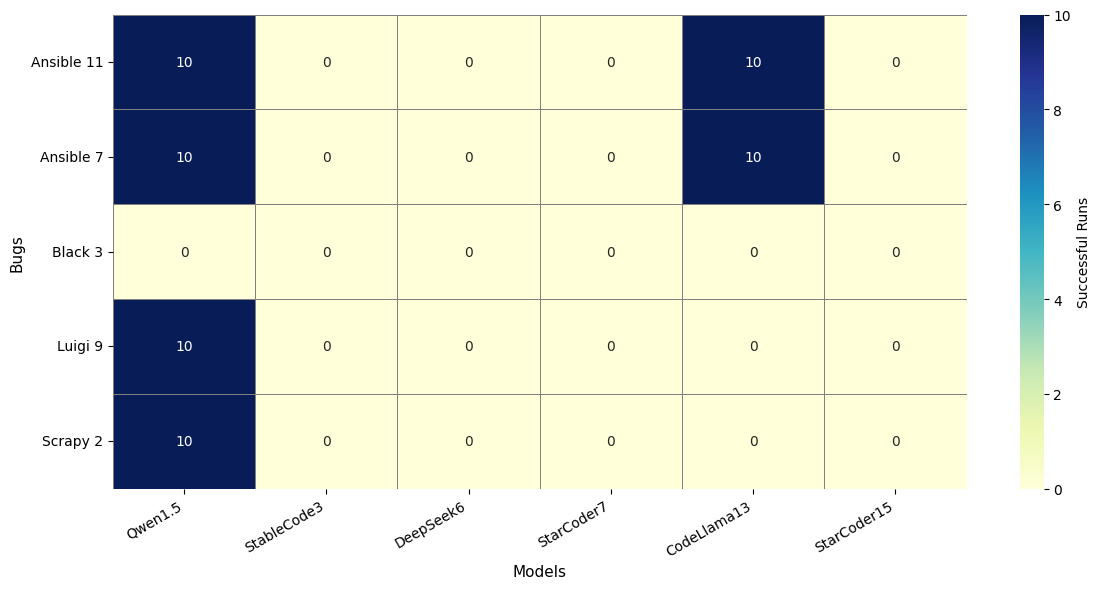

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bug_model_stats = bug_model_stats.copy()
bug_model_stats['project_clean'] = bug_model_stats['project'].str.lower()

selected_bugs = [
    ('black', 3),
    ('fastapi', 12),
    ('ansible', 7),
    ('ansible', 11),
    ('luigi', 9),
    ('scrapy', 2)
]

filtered = bug_model_stats[
    bug_model_stats.apply(
        lambda x: (x['project_clean'], int(x['bug_id'])) in selected_bugs,
        axis=1
    )
].copy()

print("Filtered bugs:")
print(filtered[['project_clean','bug_id']].drop_duplicates())

filtered['model_label'] = filtered['model'].map(model_map)

filtered['bug_label'] = (
    filtered['project_clean'].str.capitalize() + " " + filtered['bug_id'].astype(str)
)

filtered['model_label'] = pd.Categorical(
    filtered['model_label'],
    categories=model_order,
    ordered=True
)

pivot = filtered.pivot_table(
    index='bug_label',
    columns='model_label',
    values='c'
)

pivot = pivot.dropna(how='all')
pivot = pivot.fillna(0)

plt.figure(figsize=(10, 5))

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Successful Runs'}
)

plt.title("", fontsize=14, fontweight='bold')

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.xlabel("Models", fontsize=11)
plt.ylabel("Bugs", fontsize=11)

plt.tight_layout()
plt.show()

In [38]:
clean_df['duration_seconds'] = pd.to_numeric(clean_df['duration_seconds'], errors='coerce')
bug_model_time = clean_df.groupby(['model','project','bug_id']).agg({
    'duration_seconds': 'mean'
}).reset_index()
final_time = bug_model_time.groupby('model').agg({
    'duration_seconds': 'mean'
}).reset_index()
final_time['model_label'] = final_time['model'].map(model_map)

final_time['model_label'] = pd.Categorical(
    final_time['model_label'],
    categories=model_order,
    ordered=True
)

final_time = final_time.sort_values('model_label')

In [39]:
final_time = final_time.sort_values('model_label').reset_index(drop=True)

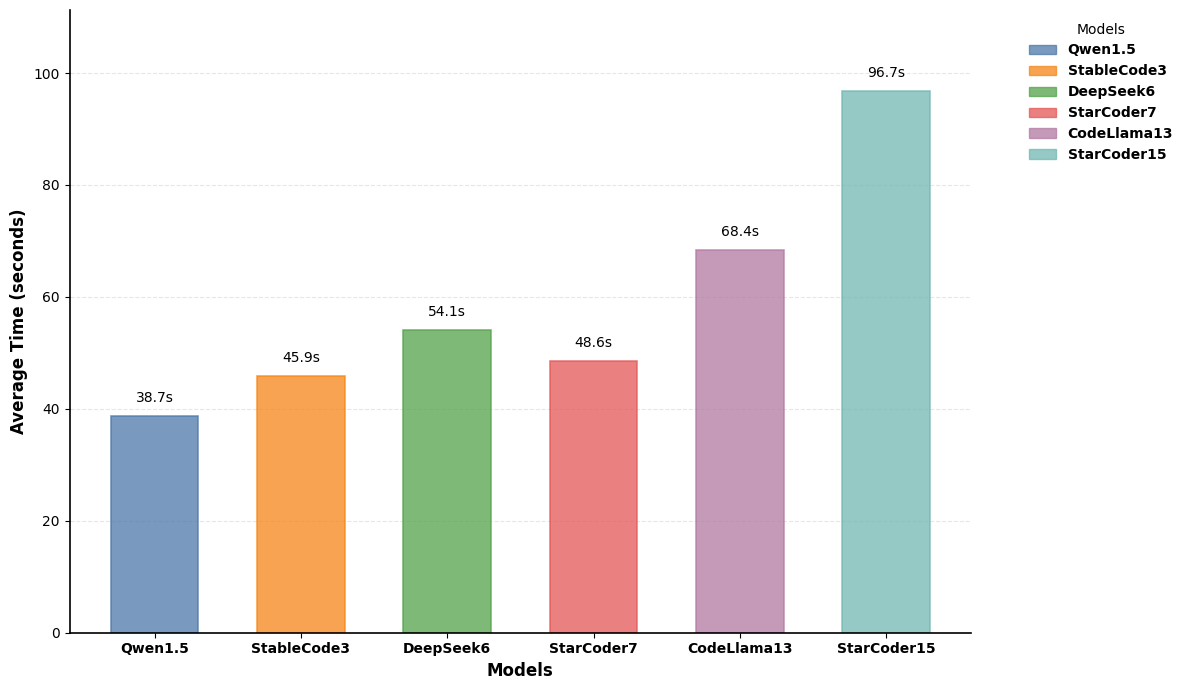

In [42]:
import matplotlib.pyplot as plt
import pandas as pd


clean_df['duration_seconds'] = pd.to_numeric(clean_df['duration_seconds'], errors='coerce')
bug_model_time = clean_df.groupby(['model','project','bug_id']).agg({
    'duration_seconds': 'mean'
}).reset_index()
final_time = bug_model_time.groupby('model').agg({
    'duration_seconds': 'mean'
}).reset_index()
final_time['model_label'] = final_time['model'].map(model_map)

final_time['model_label'] = pd.Categorical(
    final_time['model_label'],
    categories=model_order,
    ordered=True
)
final_time = final_time.sort_values('model_label').reset_index(drop=True)


plt.figure(figsize=(12, 7), facecolor='white')
ax = plt.gca()

x = range(len(final_time))
y = final_time['duration_seconds']

plt.ylim(0, max(y) * 1.15)

for i in range(len(final_time)):
    row = final_time.iloc[i]
    label = row['model_label']
    color = color_map[label]
    val = row['duration_seconds']

    plt.bar(
        i,
        val,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        alpha=0.75,
        width=0.6,
        zorder=2
    )

    plt.text(
        i,
        val + (max(y) * 0.02),
        f"{val:.1f}s",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(
    ticks=x,
    labels=final_time['model_label'],
    rotation=0,
    fontsize=10,
    fontweight='bold'
)

plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.ylabel("Average Time (seconds)", fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

handles = [
    plt.Rectangle((0,0),1,1, color=color_map[label], alpha=0.75)
    for label in model_order
]

plt.legend(handles, model_order, title="Models",
           bbox_to_anchor=(1.05, 1), loc='upper left',
           frameon=False, prop={'weight':'bold'})

plt.tight_layout()
plt.show()

In [43]:
bug_model_energy = clean_df.groupby(['model','project','bug_id']).agg({
    'llm_energy_joules': 'mean'
}).reset_index()
final_energy = bug_model_energy.groupby('model').agg({
    'llm_energy_joules': 'mean'
}).reset_index()

In [44]:
final_energy['model_label'] = final_energy['model'].map(model_map)

final_energy['model_label'] = pd.Categorical(
    final_energy['model_label'],
    categories=model_order,
    ordered=True
)

final_energy = final_energy.sort_values('model_label').reset_index(drop=True)

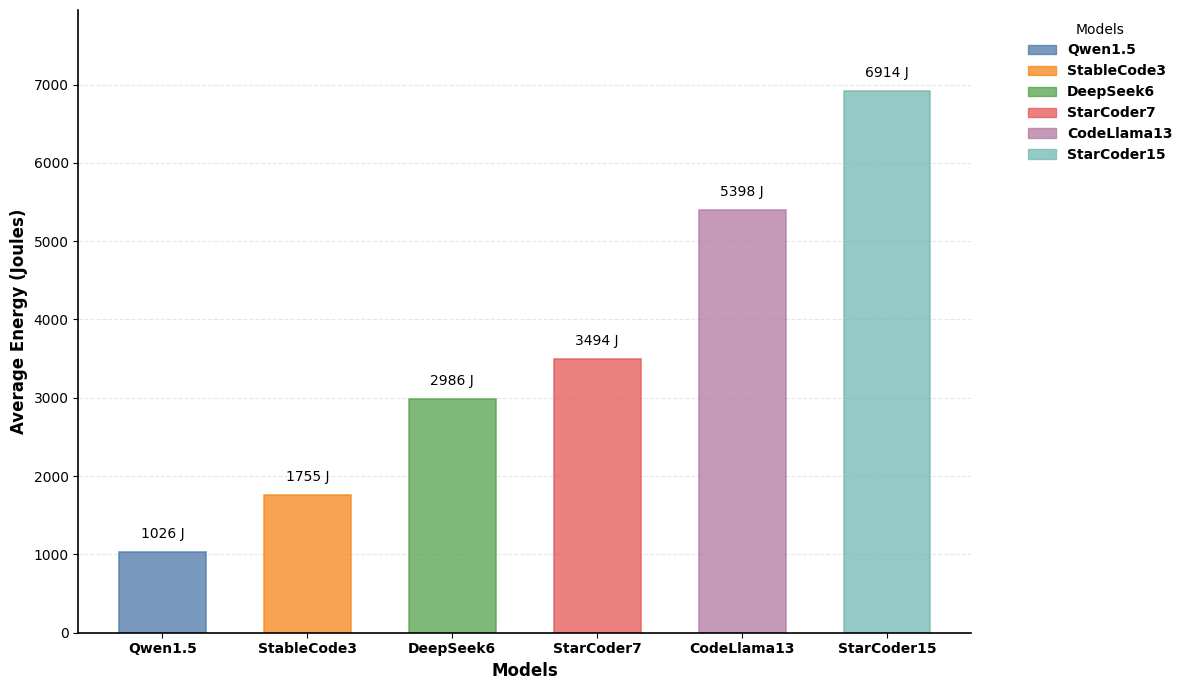

In [47]:
import matplotlib.pyplot as plt

bug_model_energy = clean_df.groupby(['model','project','bug_id']).agg({
    'llm_energy_joules': 'mean'
}).reset_index()
final_energy = bug_model_energy.groupby('model').agg({
    'llm_energy_joules': 'mean'
}).reset_index()
final_energy['model_label'] = final_energy['model'].map(model_map)

final_energy['model_label'] = pd.Categorical(
    final_energy['model_label'],
    categories=model_order,
    ordered=True
)
final_energy = final_energy.sort_values('model_label').reset_index(drop=True)

plt.figure(figsize=(12, 7), facecolor='white')
ax = plt.gca()

x = range(len(final_energy))
y = final_energy['llm_energy_joules']

plt.ylim(0, max(y) * 1.15)

for i in range(len(final_energy)):
    row = final_energy.iloc[i]
    label = row['model_label']
    color = color_map[label]
    val = row['llm_energy_joules']

    plt.bar(
        i,
        val,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        alpha=0.75,
        width=0.6,
        zorder=2
    )

    # Value label
    plt.text(
        i,
        val + (max(y) * 0.02),
        f"{int(val)} J",
        ha='center',
        va='bottom',
        fontsize=10
    )

# X-axis
plt.xticks(
    ticks=x,
    labels=final_energy['model_label'],
    rotation=0,
    fontsize=10,
    fontweight='bold'
)

# Labels
plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.ylabel("Average Energy (Joules)", fontsize=12, fontweight='bold')

# Grid + clean axes
plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

handles = [
    plt.Rectangle((0,0),1,1, color=color_map[label], alpha=0.75)
    for label in model_order
]

plt.legend(handles, model_order, title="Models",
           bbox_to_anchor=(1.05, 1), loc='upper left',
           frameon=False, prop={'weight':'bold'})

plt.tight_layout()
plt.show()

In [48]:
#Statistical Analysis:
from scipy.stats import spearmanr

# model sizes
size_map = {
    "Qwen1.5": 1.5,
    "StableCode3": 3,
    "DeepSeek6": 6.7,
    "StarCoder7": 7,
    "CodeLlama13": 13,
    "StarCoder15": 15
}

final_energy['model_size'] = final_energy['model_label'].map(size_map)

corr, p_value = spearmanr(
    final_energy['model_size'],
    final_energy['llm_energy_joules']
)

print("Spearman correlation:", corr)
print("p-value:", p_value)

Spearman correlation: 1.0
p-value: 0.0


In [49]:
from scipy.stats import friedmanchisquare, wilcoxon
import pandas as pd


if 'model_label' not in bug_model_energy.columns:
    bug_model_energy['model_label'] = bug_model_energy['model'].map(model_map)
    bug_model_energy['model_label'] = pd.Categorical(
        bug_model_energy['model_label'],
        categories=model_order,
        ordered=True
    )


pivot_energy = bug_model_energy.pivot(index=['project', 'bug_id'], columns='model_label', values='llm_energy_joules').dropna()

f_stat, p_global = friedmanchisquare(*[pivot_energy[col] for col in model_order])

print(f"Friedman Global p-value: {p_global:.4e}")

baseline = 'Qwen1.5'
stats_results = []

for model in model_order:
    if model != baseline:
        if baseline in pivot_energy.columns and model in pivot_energy.columns:
            stat, p_val = wilcoxon(pivot_energy[baseline], pivot_energy[model])
            stats_results.append({
                'Comparison': f"{baseline} vs {model}",
                'p-value': p_val,
                'Significant': p_val < 0.05
            })
        else:
            print(f"Warning: Skipping comparison {baseline} vs {model}. One or both models not found in pivot_energy columns.")

stats_df = pd.DataFrame(stats_results)
print("\nPairwise Comparisons (Qwen vs Others):")
print(stats_df)


Friedman Global p-value: 2.2938e-35

Pairwise Comparisons (Qwen vs Others):
               Comparison       p-value  Significant
0  Qwen1.5 vs StableCode3  5.820766e-11         True
1    Qwen1.5 vs DeepSeek6  5.820766e-11         True
2   Qwen1.5 vs StarCoder7  5.820766e-11         True
3  Qwen1.5 vs CodeLlama13  5.820766e-11         True
4  Qwen1.5 vs StarCoder15  5.820766e-11         True


In [50]:
import numpy as np

def vda_a12(gen, ref):
    """Calculates Vargha and Delaney's A12 effect size"""
    m, n = len(gen), len(ref)
    r = sorted(list(gen) + list(ref))
    r_gen = [r.index(x) + 1 for x in gen]
    R1 = sum(r_gen)
    A = (2 * R1 - m * (m + 1)) / (2 * m * n)

    if A > 0.71: res = "Large"
    elif A > 0.64: res = "Medium"
    elif A > 0.56: res = "Small"
    else: res = "Negligible"
    return A, res

a12_val, interpretation = vda_a12(pivot_energy['StarCoder15'], pivot_energy['Qwen1.5'])
print(f"Effect Size (A12) StarCoder15 vs Qwen1.5: {a12_val:.3f} ({interpretation})")


Effect Size (A12) StarCoder15 vs Qwen1.5: 1.000 (Large)


In [55]:
if 'model_label' not in bug_model_time.columns:
    bug_model_time['model_label'] = bug_model_time['model'].map(model_map)
    bug_model_time['model_label'] = pd.Categorical(
        bug_model_time['model_label'],
        categories=model_order,
        ordered=True
    )

pivot_time = bug_model_time.pivot(index=['project', 'bug_id'], columns='model_label', values='duration_seconds').dropna()

a12_time, interpretation_time = vda_a12(pivot_time['StarCoder15'], pivot_time['Qwen1.5'])
print(f"Effect Size (A12) for Time: {a12_time:.3f} ({interpretation_time})")

Effect Size (A12) for Time: 1.000 (Large)


/tmp/ipykernel_12122/2866799165.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


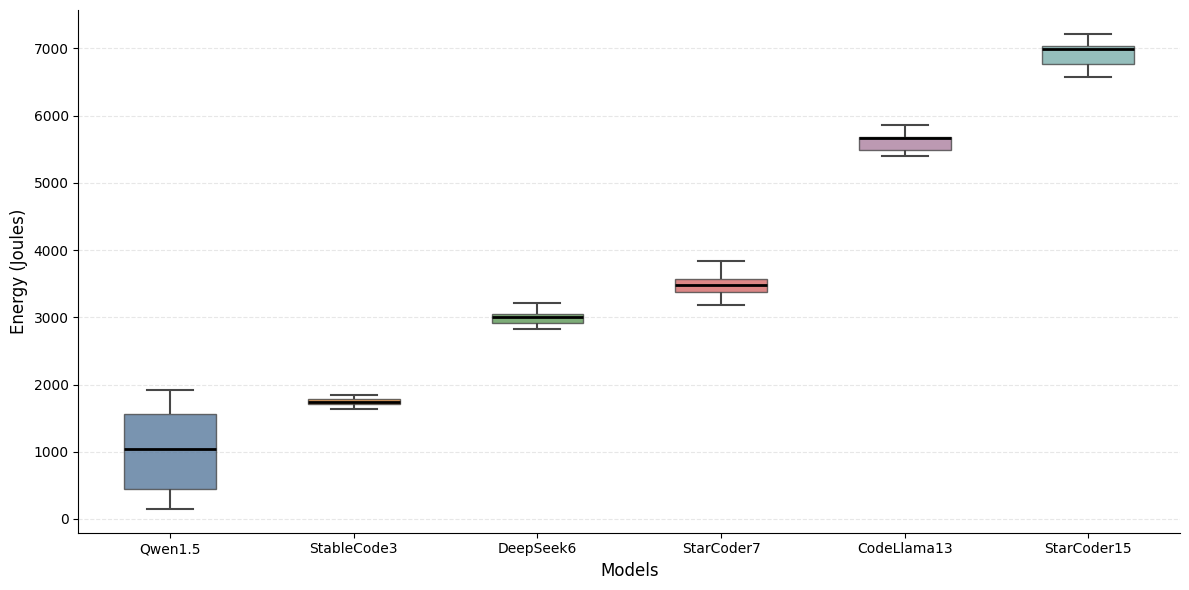

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

clean_df['model_label'] = clean_df['model'].map(model_map)
clean_df['model_label'] = pd.Categorical(
    clean_df['model_label'],
    categories=model_order,
    ordered=True
)


plt.figure(figsize=(12, 6))
ax = plt.gca()

sns.boxplot(
    x='model_label',
    y='llm_energy_joules',
    data=clean_df,
    palette=color_map,
    showfliers=False,
    width=0.5,

    medianprops=dict(color='black', linewidth=2.0),
    boxprops=dict(alpha=0.8),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)
plt.ylabel("Energy (Joules)", fontsize=12)
plt.xlabel("Models", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [66]:
import pandas as pd

baseline = 'Qwen1.5'
a12_results = []

for model in model_order:
    if model != baseline:
        A, _ = vda_a12(
            pivot_energy[model],
            pivot_energy[baseline]
        )
        a12_results.append({
            'model': model,
            'A12': A
        })

a12_df = pd.DataFrame(a12_results)

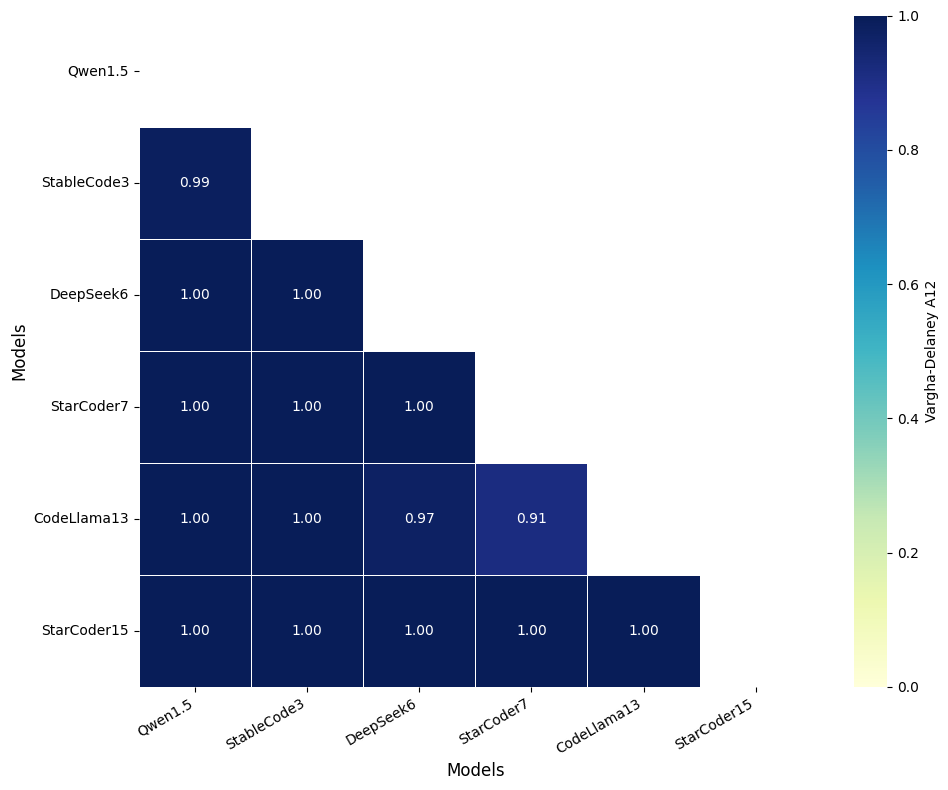

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# -------------------------------
# STEP 1: Pivot
# -------------------------------
heatmap_data = a12_matrix.pivot(
    index="Model 1",
    columns="Model 2",
    values="A12"
)

heatmap_data = heatmap_data.reindex(
    index=model_order,
    columns=model_order
)


mask = np.triu(np.ones_like(heatmap_data, dtype=bool))


color_list = [
    "#caf0f8",
    "#90e0ef",
    "#00b4d8",
    "#0077b6",
    "#023e8a",
    "#03045e"
]

custom_cmap = sns.color_palette("YlGnBu", as_cmap=True)

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    heatmap_data,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    linewidths=0.5,
    cbar_kws={'label': 'Vargha-Delaney A12'},
    vmin=0, vmax=1
)


for text in ax.texts:
    val = float(text.get_text())


    if val < 0.5:
        text.set_color("black")
    else:
        text.set_color("white")




plt.xlabel("Models", fontsize=12)
plt.ylabel("Models", fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

This plot illustrates the trade-off between model performance and energy consumption, enabling the identification of models that achieve higher accuracy at lower computational cost.

In [69]:
# Function to get A12 for all pairs
pairs = []
for m1 in model_order:
    for m2 in model_order:
        if m1 != m2:
            val, interp = vda_a12(pivot_energy[m1], pivot_energy[m2])
            pairs.append({'Model 1': m1, 'Model 2': m2, 'A12': val, 'Magnitude': interp})

a12_matrix = pd.DataFrame(pairs)
# Is table ko aap thesis ke Appendix mein ya results mein summary ke taur par de sakte hain.
print(a12_matrix)


        Model 1      Model 2       A12   Magnitude
0       Qwen1.5  StableCode3  0.013061  Negligible
1       Qwen1.5    DeepSeek6  0.000000  Negligible
2       Qwen1.5   StarCoder7  0.000000  Negligible
3       Qwen1.5  CodeLlama13  0.000000  Negligible
4       Qwen1.5  StarCoder15  0.000000  Negligible
5   StableCode3      Qwen1.5  0.986939       Large
6   StableCode3    DeepSeek6  0.000000  Negligible
7   StableCode3   StarCoder7  0.000000  Negligible
8   StableCode3  CodeLlama13  0.000000  Negligible
9   StableCode3  StarCoder15  0.000000  Negligible
10    DeepSeek6      Qwen1.5  1.000000       Large
11    DeepSeek6  StableCode3  1.000000       Large
12    DeepSeek6   StarCoder7  0.000000  Negligible
13    DeepSeek6  CodeLlama13  0.026939  Negligible
14    DeepSeek6  StarCoder15  0.000000  Negligible
15   StarCoder7      Qwen1.5  1.000000       Large
16   StarCoder7  StableCode3  1.000000       Large
17   StarCoder7    DeepSeek6  1.000000       Large
18   StarCoder7  CodeLlama13  0